In [29]:
# =====================================================
# INSTALL LIBRARIES
# =====================================================

!pip install -q transformers==4.53.2
!pip install -q datasets==4.0.0
!pip install -q evaluate==0.4.5
!pip install -q accelerate==1.8.1
!pip install -q sentencepiece
!pip install -q scikit-learn
!pip install -q seaborn

In [30]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [31]:
# =====================================================
# CHECK DEVICE
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [32]:
# =====================================================
# UPLOAD DATASET
# =====================================================

from google.colab import files

uploaded = files.upload()

Saving test.csv.zip to test.csv (2).zip
Saving train.csv.zip to train.csv (2).zip


In [33]:
# =====================================================
# LOAD DATASET
# =====================================================

train_df = pd.read_csv(

    "/content/train.csv.zip",

    header=None

)

test_df = pd.read_csv(

    "/content/test.csv.zip",

    header=None

)

In [34]:
train_df.columns = [

    "label",

    "title",

    "description"

]

test_df.columns = [

    "label",

    "title",

    "description"

]

In [35]:
train_df.head()

,label,title,description
0,Class Index,Title,Description
1,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
2,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
3,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
4,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...


In [36]:
print(train_df.shape)

print(test_df.shape)

(120001, 3)
(7601, 3)


In [37]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120001 entries, 0 to 120000
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   label        120001 non-null  object
 1   title        120001 non-null  object
 2   description  120001 non-null  object
dtypes: object(3)
memory usage: 2.7+ MB


In [38]:
train_df.describe()

,label,title,description
count,120001,120001,120001
unique,5,114351,118724
top,3,Transactions,"With the economy slowly turning up, upgrading ..."
freq,30000,39,15


In [39]:
train_df.isnull().sum()

,0
label,0
title,0
description,0


In [40]:
test_df.isnull().sum()

,0
label,0
title,0
description,0


In [41]:
train_df.dropna(inplace=True)

test_df.dropna(inplace=True)

In [42]:
train_df.drop_duplicates(inplace=True)

test_df.drop_duplicates(inplace=True)

In [43]:
train_df = train_df.iloc[1:].copy()
test_df = test_df.iloc[1:].copy()

train_df["label"] = pd.to_numeric(train_df["label"])
test_df["label"] = pd.to_numeric(test_df["label"])

train_df["label"] = train_df["label"] - 1
test_df["label"] = test_df["label"] - 1

In [44]:
label_names = {

0:"World",

1:"Sports",

2:"Business",

3:"Sci/Tech"

}

In [45]:
train_df["Category"] = train_df["label"].map(label_names)

test_df["Category"] = test_df["label"].map(label_names)

In [46]:
train_df["text"] = (

train_df["title"]

+

" "

+

train_df["description"]

)

test_df["text"] = (

test_df["title"]

+

" "

+

test_df["description"]

)

In [47]:
train_df.head()

,label,title,description,Category,text
1,2,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Business,Wall St. Bears Claw Back Into the Black (Reute...
2,2,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Business,Carlyle Looks Toward Commercial Aerospace (Reu...
3,2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Business,Oil and Economy Cloud Stocks' Outlook (Reuters...
4,2,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Business,Iraq Halts Oil Exports from Main Southern Pipe...
5,2,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...",Business,"Oil prices soar to all-time record, posing new..."


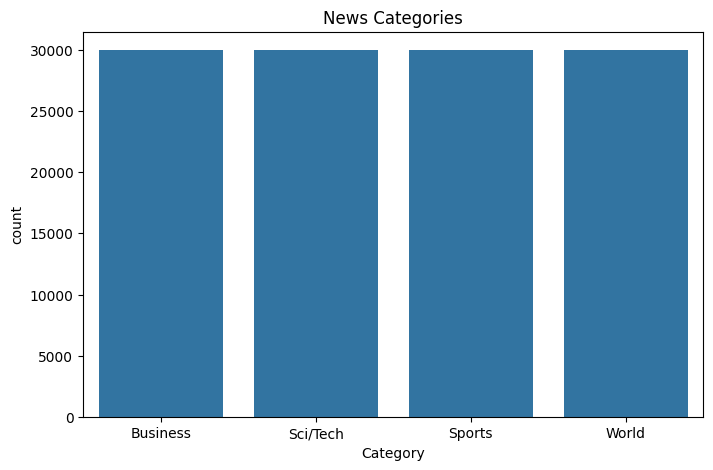

In [48]:
plt.figure(figsize=(8,5))

sns.countplot(

x=train_df["Category"]

)

plt.title("News Categories")

plt.show()

In [49]:
train_df["length"] = train_df["text"].apply(len)

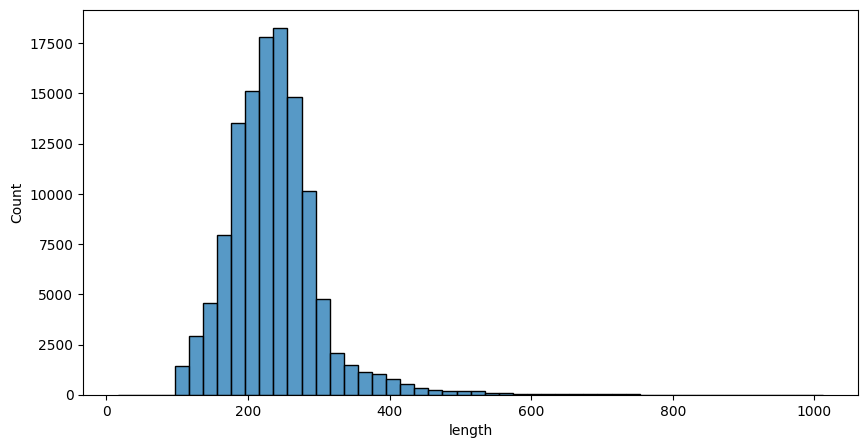

In [50]:
plt.figure(figsize=(10,5))

sns.histplot(

train_df["length"],

bins=50

)

plt.show()

In [51]:
print(train_df["Category"].value_counts())

Category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


In [52]:
train_df = train_df[

["text","label"]

]

test_df = test_df[

["text","label"]

]

In [53]:
train_df.head()

,text,label
1,Wall St. Bears Claw Back Into the Black (Reute...,2
2,Carlyle Looks Toward Commercial Aerospace (Reu...,2
3,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
4,Iraq Halts Oil Exports from Main Southern Pipe...,2
5,"Oil prices soar to all-time record, posing new...",2


In [54]:
# =====================================================
# LOAD BERT TOKENIZER
# =====================================================

MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer Loaded Successfully")

Tokenizer Loaded Successfully


In [55]:
MAX_LEN = 128

In [56]:
from torch.utils.data import Dataset

class NewsDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_len):

        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):

        return len(self.data)

    def __getitem__(self, index):

        text = str(self.data.iloc[index]["text"])

        label = int(self.data.iloc[index]["label"])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {

            "input_ids": encoding["input_ids"].flatten(),

            "attention_mask": encoding["attention_mask"].flatten(),

            "labels": torch.tensor(label, dtype=torch.long)

        }

In [57]:
train_dataset = NewsDataset(

    train_df,

    tokenizer,

    MAX_LEN

)

test_dataset = NewsDataset(

    test_df,

    tokenizer,

    MAX_LEN

)

In [58]:
print(len(train_dataset))

print(len(test_dataset))

120000
7600


In [59]:
sample = train_dataset[0]

sample

{'input_ids': tensor([  101,  2813,  2358,  1012,  6468, 15020,  2067,  2046,  1996,  2304,
          1006, 26665,  1007, 26665,  1011,  2460,  1011, 19041,  1010,  2813,
          2395,  1005,  1055,  1040, 11101,  2989,  1032,  2316,  1997, 11087,
          1011, 22330,  8713,  2015,  1010,  2024,  3773,  2665,  2153,  1012,
           102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

In [60]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False

)

In [61]:
batch = next(iter(train_loader))

print(batch["input_ids"].shape)

print(batch["attention_mask"].shape)

print(batch["labels"].shape)

torch.Size([16, 128])
torch.Size([16, 128])
torch.Size([16])


In [62]:
model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=4

)

model.to(device)

print("Model Loaded Successfully")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model Loaded Successfully


In [63]:
from transformers import AdamW

optimizer = AdamW(

    model.parameters(),

    lr=2e-5

)

ImportError: cannot import name 'AdamW' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)

In [65]:
from torch.optim import AdamW

optimizer = AdamW(

    model.parameters(),

    lr=2e-5

)

In [66]:
criterion = torch.nn.CrossEntropyLoss()

In [67]:
EPOCHS = 3

In [68]:
from transformers import get_linear_schedule_with_warmup

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(

    optimizer,

    num_warmup_steps=0,

    num_training_steps=total_steps

)

In [69]:
print(model)

print()

print("Training Batches :", len(train_loader))

print("Testing Batches :", len(test_loader))

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e